In [1]:
import os
import re
import zipfile
import requests
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
# 1. Download dataset from Zenodo

url = "https://zenodo.org/api/records/7394851/files-archive"
zip_path = "news_spam_dataset.zip"
extract_dir = "news_spam_dataset"

if not os.path.exists(zip_path):
    print("Downloading dataset...")
    r = requests.get(url, stream=True)
    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024):
            if chunk:
                f.write(chunk)
else:
    print("Dataset already downloaded.")

In [3]:
# 2. Extract files

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Files extracted to", extract_dir)
else:
    print("Already extracted.")

Files extracted to news_spam_dataset


In [ ]:
# 3. Load CSV file

csv_file = [f for f in os.listdir(extract_dir) if f.endswith(".csv")][0]
data_path = os.path.join(extract_dir, csv_file)

df = pd.read_csv(data_path)
print("Data loaded. Shape:", df.shape)
print(df.head())


Data loaded. Shape: (10917, 13)
   data_id                                                 id        date  \
0     1809  abcnews--2019-10-31--Virginia mom charged with...  2019-10-31   
1     1980  abcnews--2019-11-07--2 escaped murder suspects...  2019-11-07   
2     1995  abcnews--2019-11-07--Family turns in escaped b...  2019-11-07   
3     2740  abcnews--2019-12-02--Mother charged with murde...  2019-12-02   
4     7038  ageofautism--2019-04-12--Physician Father and ...  2019-04-12   

        source                                              title  \
0      abcnews  Virginia mom charged with murder in 2-year-old...   
1      abcnews  2 escaped murder suspects arrested at US-Mexic...   
2      abcnews  Family turns in escaped boy, 13, suspected in ...   
3      abcnews  Mother charged with murder in deaths of 2 youn...   
4  ageofautism  Physician, Father and Caretaker of 29 Year Old...   

                                             content         author  \
0  The Virginia wom

In [ ]:
import os, re, math, datetime as dt
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ----------------------------
# 0. Load data
# ----------------------------

df = pd.read_csv(data_path)

# Basic required columns from uploaded Zenodo CSV file
assert {'data_id','title','content','source','category_level_1','category_level_2','published'}.issubset(df.columns)

# 1. Clean text helpers
def clean_text(s):
    if pd.isna(s): return ""
    s = str(s)
    s = re.sub(r"http\S+|www\S+", " ", s)
    s = re.sub(r"<.*?>", " ", s)
    s = s.replace("\n"," ").strip()
    return s

df['title']   = df['title'].apply(clean_text)
df['content'] = df['content'].apply(clean_text)

# Handle published datetime
def to_dt(s):
    try:
        s = re.sub(r'\b(PST|EST|UT|CST|MST|EDT|PDT|GMT|BST|CET|CEST|IST|JST|KST|AEST|AEDT|UTC)\b', '', str(s))
        s = s.strip()
        return pd.to_datetime(s, errors='coerce')
    except:
        return pd.NaT

df['published_dt'] = df['published'].apply(to_dt)
df['published_dt'] = pd.to_datetime(df['published_dt'], errors='coerce')
df['published_dt'] = df['published_dt'].dt.tz_localize(None)

# 2. Labelling functions (LFs)
# Each returns +1 (spam), -1 (legit), 0 (abstain)

CLICKBAIT_PATTERNS = [
    r"you won't believe", r"shocking", r"what happens next", r"this one trick",
    r"top \d+", r"reasons why", r"revealed", r"secret(s)?", r"hidden truth",
    r"must see", r"miracle", r"epic", r"jaw[- ]?dropping", r"unbelievable"
]
CLICKBAIT_RE = re.compile("|".join(CLICKBAIT_PATTERNS), re.IGNORECASE)

def lf_clickbait_title(row):
    title = row['title']
    if not title: return 0
    return 1 if CLICKBAIT_RE.search(title) else 0

def lf_excess_punct_caps(row):
    t = row['title']
    if not t: return 0
    excl = t.count("!")
    ques = t.count("?")
    caps_ratio = sum(1 for c in t if c.isupper()) / max(1,len(t))
    # spam if too many ! or ? or caps heavy
    if excl >= 2 or ques >= 2 or caps_ratio > 0.35:
        return 1
    return 0

def lf_length_extremes(row):
    words = len(row['content'].split())
    if words == 0: return 1  # empty content suspicious
    # too short or excessively long can be suspicious depending on your corpus
    if words < 40:  # too short
        return 1
    if words > 2500:  # extreme long-form in this corpus may be duplicates / dumps
        return 1
    return 0

def lf_source_rarity(row, source_counts, rare_thresh=10):
    src = row['source']
    if not src: return 0
    # very rare sources → higher spam in weak supervision
    return 1 if source_counts.get(src,0) <= rare_thresh else 0

def lf_duplicate_titles(row, title_counts, dup_thresh=3):
    t = row['title'].lower().strip()
    if not t: return 0
    # if exact same title appears many times across sources/dates, treat as spammy
    return 1 if title_counts.get(t,0) >= dup_thresh else 0

# Title-content semantic mismatch via TF-IDF
def build_title_content_cosine(df, sample_max=15000):
    df_s = df.sample(min(len(df), sample_max), random_state=42).copy()
    texts = list(df_s['title'].fillna("") + " " + df_s['content'].fillna(""))
    vec = TfidfVectorizer(min_df=5, max_df=0.9, ngram_range=(1,2))
    X = vec.fit_transform(texts)

    # Compute per-row cosine between title-only and content-only reps:
    title_only = vec.transform(df_s['title'].fillna(""))
    content_only = vec.transform(df_s['content'].fillna(""))

    sims = cosine_similarity(title_only, content_only).diagonal()
    df_s['title_content_cosine'] = sims
    return df_s[['title','content','title_content_cosine']]

tc_cos = build_title_content_cosine(df)
tc_map = dict(zip(tc_cos['title'] + "||" + tc_cos['content'], tc_cos['title_content_cosine']))

def lf_title_content_mismatch(row, thresh=0.02):
    key = (row['title'] or "") + "||" + (row['content'] or "")
    v = tc_map.get(key, None)
    if v is None:
        return 0
    # extremely low similarity between title and content → likely spam/clickbait
    return 1 if v < thresh else 0

def lf_burstiness(row, source_time_index, window_minutes=30, burst_thresh=20):
    """If a source publishes a burst of >= burst_thresh items within window → suspicious."""
    src = row['source']
    t = row['published_dt']
    if pd.isna(t) or not src: return 0
    # count how many from that source within +/- window
    times = source_time_index.get(src, [])
    # binary search would be faster; linear for simplicity if small
    cnt = 0
    low = t - pd.Timedelta(minutes=window_minutes)
    high = t + pd.Timedelta(minutes=window_minutes)
    # early exit if times empty
    if not times: return 0
    # naive count
    for ti in times:
        if low <= ti <= high:
            cnt += 1
            if cnt >= burst_thresh:
                return 1
    return 0

# Precompute stats needed for LFs
source_counts = Counter(df['source'].fillna(""))
title_counts  = Counter(df['title'].fillna("").str.lower().str.strip())

source_time_index = defaultdict(list)
for src, ts in zip(df['source'], df['published_dt']):
    if pd.isna(ts) or not src: continue
    source_time_index[src].append(ts)
for k in source_time_index:
    source_time_index[k].sort()


# 3. Apply LFs and combine
LF_LIST = [
    ('clickbait_title', lambda r: lf_clickbait_title(r)),
    ('excess_punct_caps', lambda r: lf_excess_punct_caps(r)),
    ('length_extremes', lambda r: lf_length_extremes(r)),
    ('source_rarity', lambda r: lf_source_rarity(r, source_counts)),
    ('duplicate_titles', lambda r: lf_duplicate_titles(r, title_counts)),
    ('title_content_mismatch', lambda r: lf_title_content_mismatch(r)),
    ('burstiness', lambda r: lf_burstiness(r, source_time_index)),
]

def apply_lfs(row):
    votes = []
    for name, func in LF_LIST:
        try:
            v = func(row)
        except Exception:
            v = 0
        # Map LF outputs to {-1,0,+1}; LFs emit 0 or +1 (spam), so treat no-vote as 0; legit vote (-1) not used here
        votes.append(v)
    return votes

lf_votes = df.apply(apply_lfs, axis=1, result_type='expand')
lf_votes.columns = [name for name,_ in LF_LIST]
df = pd.concat([df, lf_votes], axis=1)

# Majority vote with tie=abstain (0)
vote_array = lf_votes.values
spam_score = vote_array.sum(axis=1)           # number of LFs marking spam
num_lfs    = (vote_array != 0).sum(axis=1)    # count of active LFs
majority   = (spam_score > (num_lfs / 2)).astype(int)  # 1=spam if >50% of active votes
abstain    = (num_lfs == 0)
majority[abstain] = 0  # abstain -> default legit (or drop)

# Confidence: fraction of active LFs voting spam
with np.errstate(divide='ignore', invalid='ignore'):
    confidence = np.where(num_lfs>0, spam_score/num_lfs, 0.0)

df['spam_label_weak'] = majority
df['spam_confidence'] = confidence

# Save weak labels for traceability
os.makedirs("weak_labels", exist_ok=True)
df[['data_id','title','content','source','category_level_1','category_level_2','published','spam_label_weak','spam_confidence'] + list(lf_votes.columns)]\
  .to_csv("weak_labels/with_votes.csv", index=False)

print("Weak labels created. Spam rate:", df['spam_label_weak'].mean().round(3),
      "| abstain-as-legit count:", int((num_lfs==0).sum()))

total_articles = len(df)
spam_articles = df['spam_label_weak'].sum()

print(f"Total news articles: {total_articles}")
print(f"Spam-labeled articles: {spam_articles}")

Weak labels created. Spam rate: 0.118 | abstain-as-legit count: 9627
Total news articles: 10917
Spam-labeled articles: 1290


In [ ]:
#5. finalize label, category, meta-data and create train, val & test splits

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# Load weakly labeled data
df = pd.read_csv("weak_labels/with_votes.csv")

# Safety cleanups
df['title'] = df['title'].fillna("").astype(str)
df['content'] = df['content'].fillna("").astype(str)
df['source'] = df['source'].fillna("UNKNOWN").astype(str)
df['category_level_1'] = df['category_level_1'].fillna("UNK_CAT1").astype(str)
df['category_level_2'] = df['category_level_2'].fillna("UNK_CAT2").astype(str)

# Combine text (simple baseline input)
df['text'] = (df['title'] + " " + df['content']).str.strip()

# Drop empty texts if any
df = df[df['text'].str.strip() != ""].reset_index(drop=True)

# de-noising by confidence
# Keep only confident positives/negatives
KEEP_MARGIN = False
POS_T = 0.60   # keep spam if confidence >= 0.60
NEG_T = 0.40   # keep legit if confidence <= 0.40

if KEEP_MARGIN:
    pos = df[(df['spam_label_weak']==1) & (df['spam_confidence']>=POS_T)]
    neg = df[(df['spam_label_weak']==0) & (df['spam_confidence']<=NEG_T)]
    df = pd.concat([pos, neg]).sample(frac=1, random_state=42).reset_index(drop=True)

# Encode categories & metadata
le_cat1 = LabelEncoder()
df['category_encoded'] = le_cat1.fit_transform(df['category_level_1'].astype(str))

le_source = LabelEncoder()
df['source_encoded'] = le_source.fit_transform(df['source'].astype(str))

# derive simple time features from 'published'
def safe_to_datetime(s):
    try:
        s = re.sub(r'\b(PST|EST|UT|CST|MST|EDT|PDT|GMT|BST|CET|CEST|IST|JST|KST|AEST|AEDT|UTC)\b', '', str(s))
        s = s.strip()
        return pd.to_datetime(s, errors='coerce')
    except:
        return pd.NaT

df['published_dt'] = df['published'].apply(safe_to_datetime)
df['published_dt'] = pd.to_datetime(df['published_dt'], errors='coerce')
df['year'] = df['published_dt'].dt.year.fillna(-1).astype(int)
df['month'] = df['published_dt'].dt.month.fillna(-1).astype(int)
df['day'] = df['published_dt'].dt.day.fillna(-1).astype(int)

# Train/Val/Test splits
# Stratify by spam to keep balance across splits
train_df, test_df = train_test_split(df, test_size=0.15, random_state=42, stratify=df['spam_label_weak'])
train_df, val_df  = train_test_split(train_df, test_size=0.15, random_state=42, stratify=train_df['spam_label_weak'])

print("Split sizes:", len(train_df), len(val_df), len(test_df))
print("Spam rates -> train:", train_df['spam_label_weak'].mean().round(3),
      "val:", val_df['spam_label_weak'].mean().round(3),
      "test:", test_df['spam_label_weak'].mean().round(3))


# Binary class weights for spam head
def compute_class_weights(y):
    counts = Counter(y)
    # weight = N / (2 * count_class)
    N = len(y)
    w0 = N / (2.0 * counts.get(0, 1))
    w1 = N / (2.0 * counts.get(1, 1))
    return {0: w0, 1: w1}

spam_class_weights = compute_class_weights(train_df['spam_label_weak'].astype(int))
print("Spam class weights:", spam_class_weights)

# Category class weights 
def compute_mc_weights(y):
    counts = Counter(y)
    N = len(y)
    classes = sorted(counts.keys())
    w = {c: N / (len(classes) * counts[c]) for c in classes}
    return w

cat_class_weights = compute_mc_weights(train_df['category_encoded'].astype(int))
print("Category class weights (dict of class_index -> weight):",
      dict(list(cat_class_weights.items())[:10]), "...")

# Save processed CSVs
os.makedirs("processed", exist_ok=True)
train_df.to_csv("processed/train.csv", index=False)
val_df.to_csv("processed/val.csv", index=False)
test_df.to_csv("processed/test.csv", index=False)

# Save label maps for reproducibility
pd.Series(le_cat1.classes_).to_csv("processed/category_level_1_labels.csv", index_label="index", header=["label"])
pd.Series(le_source.classes_).to_csv("processed/source_labels.csv", index_label="index", header=["label"])

# Save class weights for training-time use
import json
with open("processed/spam_class_weights.json","w") as f:
    json.dump(spam_class_weights, f, indent=2)
with open("processed/category_class_weights.json","w") as f:
    json.dump(cat_class_weights, f, indent=2)

print("✔ Preprocessing complete. Files saved in /processed")


Split sizes: 7887 1392 1638
Spam rates -> train: 0.118 val: 0.118 test: 0.118
Spam class weights: {0: 0.5670021567217829, 1: 4.231223175965665}
Category class weights (dict of class_index -> weight): {0: 2.1088235294117648, 1: 0.7784247927358863, 2: 1.2816054598635034, 3: 1.2923152547927248, 4: 1.6165197786431647, 5: 1.0665314401622719, 6: 1.0764296437832674, 7: 0.9506991321118612, 8: 1.0520208083233293, 9: 0.9150713539853811} ...
✔ Preprocessing complete. Files saved in /processed


Saved EDA plots to processed/


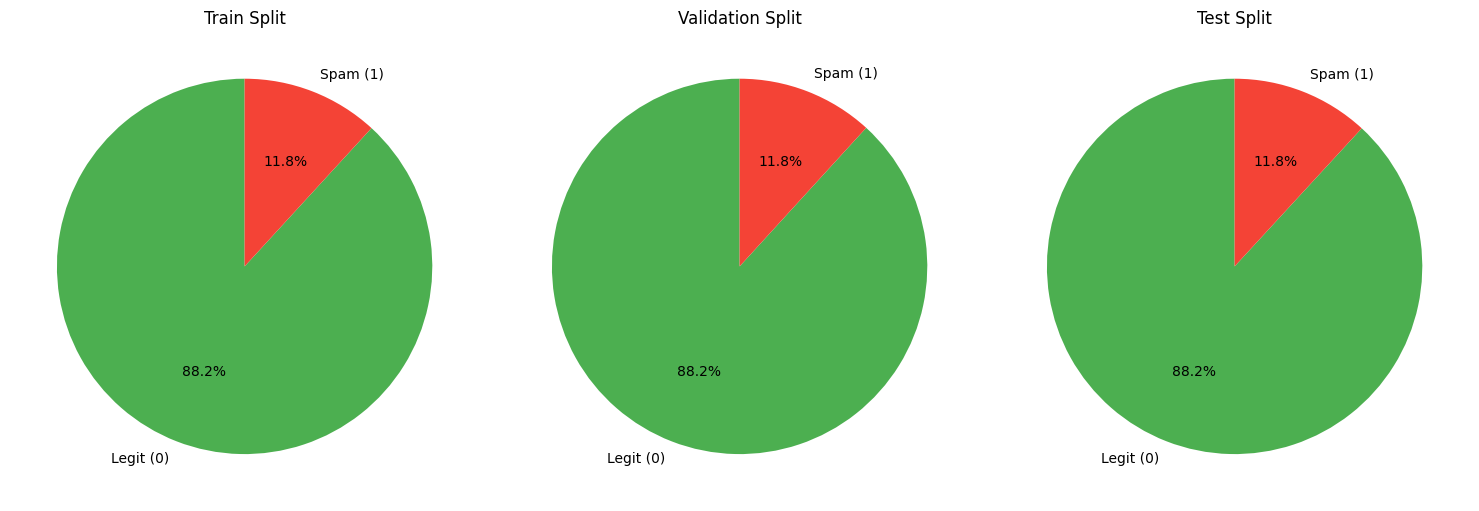

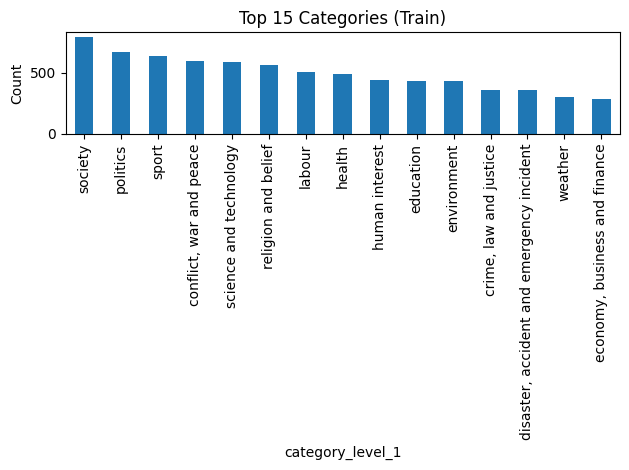

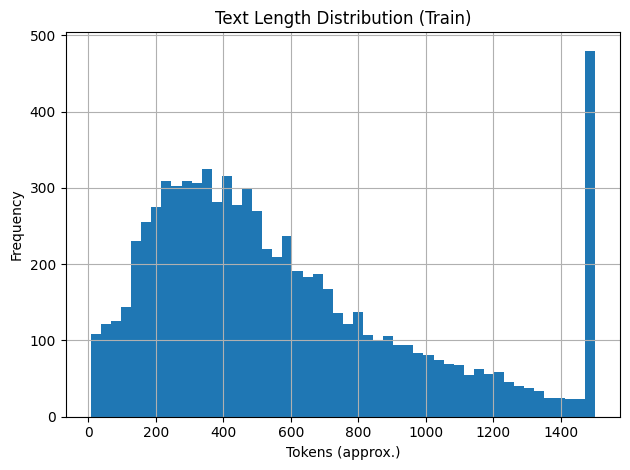

In [ ]:
#6. Data visualization after preprocessing

import matplotlib.pyplot as plt

#Spam distribution in train, val, test sets
splits = [('Train', train_df), ('Validation', val_df), ('Test', test_df)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, d) in zip(axes, splits):
    counts = d['spam_label_weak'].value_counts().sort_index()
    labels = ['Legit (0)', 'Spam (1)']
    ax.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#4CAF50','#F44336'])
    ax.set_title(f"{name} Split")

plt.tight_layout()
plt.savefig("processed/eda_spam_distribution.png")

# Category counts (top 15)
top_cats = train_df['category_level_1'].value_counts().head(15)
plt.figure()
top_cats.plot(kind='bar')
plt.title("Top 15 Categories (Train)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("processed/eda_top_categories_train.png")

# Text length hist
train_df['len_text'] = train_df['text'].str.split().apply(len)
plt.figure()
train_df['len_text'].clip(0, 1500).hist(bins=50)
plt.title("Text Length Distribution (Train)")
plt.xlabel("Tokens (approx.)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("processed/eda_len_hist_train.png")

print("Saved EDA plots to processed/")


In [ ]:
#7. Experiment 1 - Train a simple model (TF-IDF + Logistic Regression) with weak labels

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score


# 1. Load data
train_df = pd.read_csv("processed/train.csv")
val_df   = pd.read_csv("processed/val.csv")
test_df  = pd.read_csv("processed/test.csv")

if "text" in train_df.columns:
    train_texts = train_df["text"].fillna("").astype(str)
    val_texts   = val_df["text"].fillna("").astype(str)
    test_texts  = test_df["text"].fillna("").astype(str)
else:
    train_texts = (train_df["title"].fillna("") + " " + train_df["content"].fillna("")).astype(str)
    val_texts   = (val_df["title"].fillna("") + " " + val_df["content"].fillna("")).astype(str)
    test_texts  = (test_df["title"].fillna("") + " " + test_df["content"].fillna("")).astype(str)

train_labels = train_df["spam_label_weak"].astype(int)
val_labels   = val_df["spam_label_weak"].astype(int)
test_labels  = test_df["spam_label_weak"].astype(int)


# 2. TF-IDF vectorizer

tfidf = TfidfVectorizer(
    min_df=5,           # ignore rare terms
    max_df=0.9,         # ignore very common terms
    ngram_range=(1,2),  # unigrams + bigrams
    max_features=50000  # limit features for speed
)

X_train = tfidf.fit_transform(train_texts)
X_val   = tfidf.transform(val_texts)
X_test  = tfidf.transform(test_texts)


# 3. Logistic Regression
lr = LogisticRegression(max_iter=2000, class_weight="balanced")  # balanced handles imbalance
lr.fit(X_train, train_labels)


# 4. Evaluate
def evaluate(model, X, y, split_name="Val"):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:,1]
    print(f"\n=== {split_name} Results ===")
    print(classification_report(y, preds, digits=3))
    print(f"ROC-AUC: {roc_auc_score(y, probs):.3f}")

evaluate(lr, X_val, val_labels, "Validation")
evaluate(lr, X_test, test_labels, "Test")



=== Validation Results ===
              precision    recall  f1-score   support

           0      0.936     0.897     0.916      1228
           1      0.414     0.543     0.470       164

    accuracy                          0.856      1392
   macro avg      0.675     0.720     0.693      1392
weighted avg      0.875     0.856     0.864      1392

ROC-AUC: 0.813

=== Test Results ===
              precision    recall  f1-score   support

           0      0.926     0.890     0.908      1444
           1      0.367     0.474     0.413       194

    accuracy                          0.841      1638
   macro avg      0.646     0.682     0.661      1638
weighted avg      0.860     0.841     0.849      1638

ROC-AUC: 0.784



TFIDF+LR Confusion Matrix (Val)
[[1102  126]
 [  75   89]]


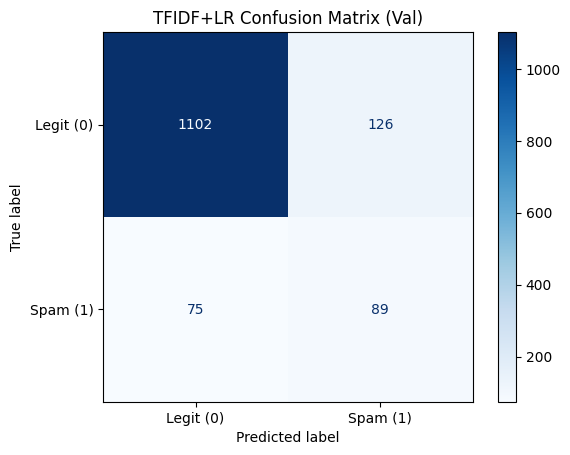


TFIDF+LR Confusion Matrix (Test)
[[1285  159]
 [ 102   92]]


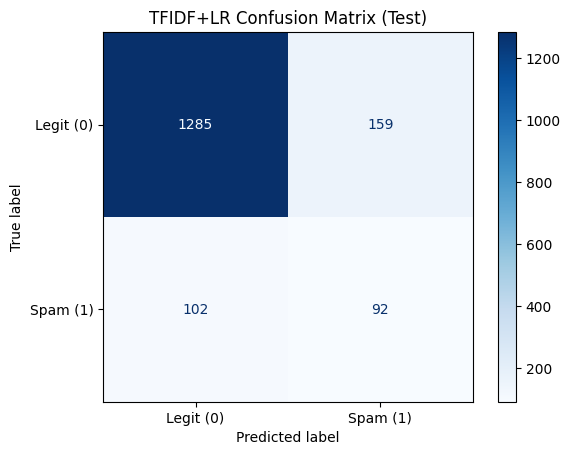

In [ ]:
#8. Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def show_cm(model, X, y, title):
    preds = model.predict(X)
    cm = confusion_matrix(y, preds, labels=[0,1])

    print(f"\n{title}")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit (0)', 'Spam (1)'])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

# Call for val/test
show_cm(lr, X_val,  val_labels,  "TFIDF+LR Confusion Matrix (Val)")
show_cm(lr, X_test, test_labels, "TFIDF+LR Confusion Matrix (Test)")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1: Train loss 0.8084 F1 0.142 | Val loss 0.6722 Acc 0.899 P 0.960 R 0.146 F1 0.254 AUC 0.752
Epoch 2: Train loss 0.7062 F1 0.303 | Val loss 0.6356 Acc 0.905 P 0.758 R 0.287 F1 0.416 AUC 0.780
Epoch 3: Train loss 0.8161 F1 0.344 | Val loss 0.8698 Acc 0.909 P 0.849 R 0.274 F1 0.415 AUC 0.785

Best threshold on Validation: 0.28 (F1=0.495)

[Validation] @th=0.28
Acc 0.897 | Precision 0.588 | Recall 0.427 | F1 0.495 | ROC-AUC 0.785

Classification report:
              precision    recall  f1-score   support

           0      0.926     0.960     0.943      1228
           1      0.588     0.427     0.495       164

    accuracy                          0.897      1392
   macro avg      0.757     0.693     0.719      1392
weighted avg      0.886     0.897     0.890      1392



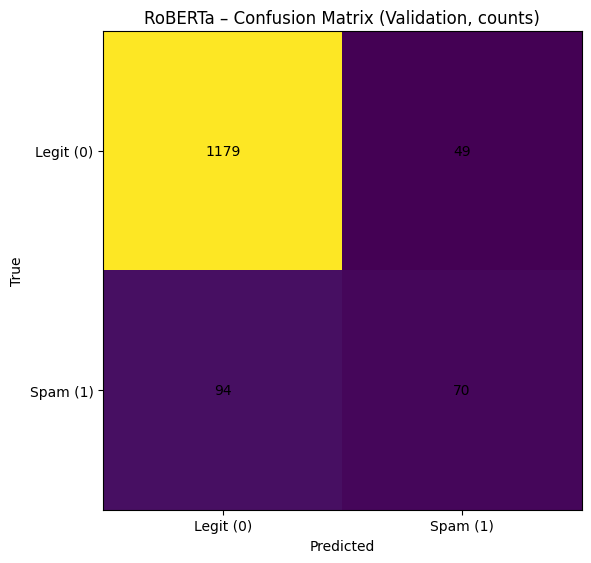

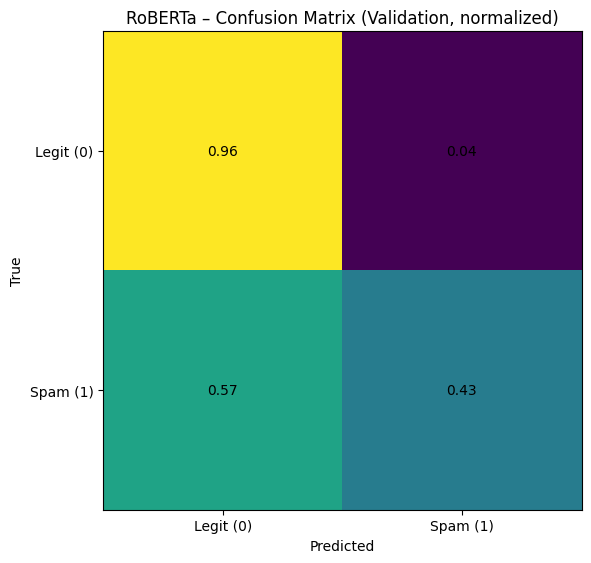


[Test] @th=0.28
Acc 0.882 | Precision 0.500 | Recall 0.366 | F1 0.423 | ROC-AUC 0.765

Classification report:
              precision    recall  f1-score   support

           0      0.918     0.951     0.934      1444
           1      0.500     0.366     0.423       194

    accuracy                          0.882      1638
   macro avg      0.709     0.658     0.678      1638
weighted avg      0.868     0.882     0.873      1638



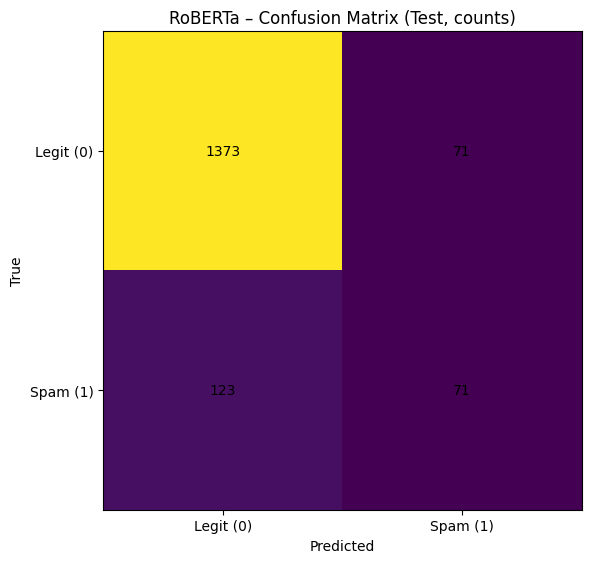

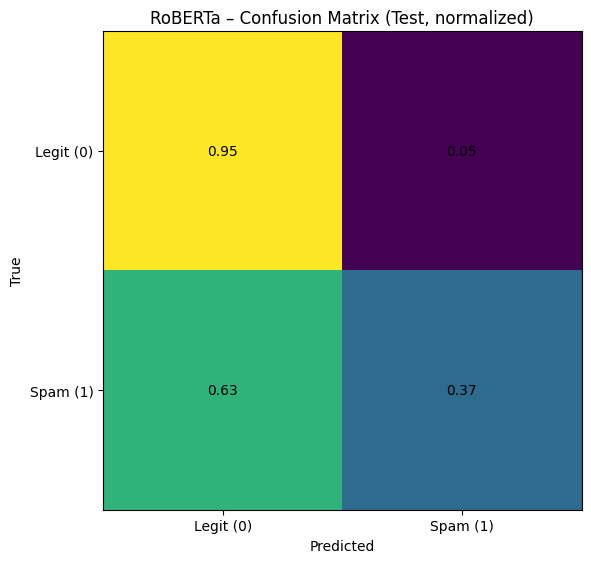

In [ ]:
#9 Experiment 2: RoBERTa single-task spam detection

import os, random, numpy as np, pandas as pd, torch
import torch.nn.functional as F
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import (precision_recall_fscore_support, accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

# Config
MODEL_NAME = "roberta-base"
MAX_LEN = 192
BATCH_TRAIN = 8
BATCH_EVAL  = 32
EPOCHS = 3
LR = 2e-5
USE_SAMPLE_CONFIDENCE = False  
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load data
train = pd.read_csv("processed/train.csv")
val   = pd.read_csv("processed/val.csv")
test  = pd.read_csv("processed/test.csv")

def get_text(df):
    if "text" in df.columns: return df["text"].fillna("").astype(str)
    return (df["title"].fillna("") + " " + df["content"].fillna("")).astype(str)

train_texts = get_text(train)
val_texts   = get_text(val)
test_texts  = get_text(test)

y_train = train["spam_label_weak"].astype(int).values
y_val   = val["spam_label_weak"].astype(int).values
y_test  = test["spam_label_weak"].astype(int).values

# class weights
def compute_class_weights(y):
    c = Counter(y); N = len(y)
    w0 = N / (2.0 * c.get(0,1)); w1 = N / (2.0 * c.get(1,1))
    return torch.tensor([w0, w1], dtype=torch.float)
CLASS_WEIGHTS = compute_class_weights(y_train).to(DEVICE)

conf_train = train.get("spam_confidence", pd.Series(np.ones(len(train)))).astype(float).values
conf_val   = val.get("spam_confidence",   pd.Series(np.ones(len(val)))).astype(float).values
conf_test  = test.get("spam_confidence",  pd.Series(np.ones(len(test)))).astype(float).values

# Dataloaders
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

class SpamDataset(Dataset):
    def __init__(self, texts, labels, confidences):
        self.texts = list(texts); self.labels = labels; self.conf = confidences
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        enc = tokenizer(self.texts[idx], truncation=True, padding="max_length", max_length=MAX_LEN)
        item = {k: torch.tensor(v) for k,v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        item["conf"]   = torch.tensor(self.conf[idx], dtype=torch.float)
        return item

dl_train = DataLoader(SpamDataset(train_texts, y_train, conf_train), batch_size=BATCH_TRAIN, shuffle=True)
dl_val   = DataLoader(SpamDataset(val_texts,   y_val,   conf_val),   batch_size=BATCH_EVAL)
dl_test  = DataLoader(SpamDataset(test_texts,  y_test,  conf_test),  batch_size=BATCH_EVAL)

# Model + Optim
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR)
num_steps = len(dl_train) * EPOCHS
sched = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*num_steps), num_training_steps=num_steps)

# Train / Eval loop
def run_epoch(dataloader, model, optimizer=None, scheduler=None, class_weights=None, use_sample_conf=True, device=DEVICE):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss, preds_all, probs_all, y_all = 0.0, [], [], []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention = batch["attention_mask"].to(device)
        labels    = batch["labels"].to(device)
        conf      = batch["conf"].to(device)

        logits = model(input_ids=input_ids, attention_mask=attention).logits
        ce = torch.nn.functional.cross_entropy(logits, labels, reduction='none', weight=class_weights)
        loss_vec = ce * conf if use_sample_conf else ce
        loss = loss_vec.mean()

        if train_mode:
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            if scheduler is not None: scheduler.step()

        total_loss += loss.item() * labels.size(0)
        with torch.no_grad():
            prob1 = torch.softmax(logits, dim=-1)[:,1]
            pred  = (prob1 >= 0.5).long()
            preds_all.append(pred.cpu().numpy())
            probs_all.append(prob1.cpu().numpy())
            y_all.append(labels.cpu().numpy())

    y_all = np.concatenate(y_all); preds = np.concatenate(preds_all); probs = np.concatenate(probs_all)
    avg_loss = total_loss / len(y_all)
    p,r,f1,_ = precision_recall_fscore_support(y_all, preds, average='binary', zero_division=0)
    acc = accuracy_score(y_all, preds)
    auc = roc_auc_score(y_all, probs)
    return avg_loss, acc, p, r, f1, auc, (y_all, probs)

def threshold_sweep(y_true, y_prob, lo=0.2, hi=0.8, steps=25):
    from sklearn.metrics import f1_score
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(lo, hi, steps):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f1 > best_f1: best_f1, best_t = f1, float(t)
    return best_t, best_f1

def show_cm(y_true, y_pred, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(cm, interpolation='nearest')
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Legit (0)','Spam (1)']); ax.set_yticklabels(['Legit (0)','Spam (1)'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:.2f}" if normalize else f"{cm[i,j]:.0f}", ha="center", va="center")
    plt.tight_layout(); plt.show()

# Train loop with Validation
best_f1 = -1.0
for epoch in range(1, EPOCHS+1):
    tr = run_epoch(dl_train, model, optimizer, sched, CLASS_WEIGHTS, USE_SAMPLE_CONFIDENCE, DEVICE)
    va = run_epoch(dl_val,   model, None,      None,  CLASS_WEIGHTS, USE_SAMPLE_CONFIDENCE, DEVICE)
    print(f"Epoch {epoch}: "
          f"Train loss {tr[0]:.4f} F1 {tr[4]:.3f} | "
          f"Val loss {va[0]:.4f} Acc {va[1]:.3f} P {va[2]:.3f} R {va[3]:.3f} F1 {va[4]:.3f} AUC {va[5]:.3f}")
    best_f1 = max(best_f1, va[4])

# Threshold tuning on Val, final eval on Test
_, _, _, _, _, _, (y_val_true, y_val_prob) = run_epoch(dl_val, model, None, None, CLASS_WEIGHTS, USE_SAMPLE_CONFIDENCE, DEVICE)
t_star, f1_star = threshold_sweep(y_val_true, y_val_prob, lo=0.2, hi=0.8, steps=25)
print(f"\nBest threshold on Validation: {t_star:.2f} (F1={f1_star:.3f})")

# Evaluate and show results
def eval_and_show(dataloader, split_name):
    y_true, y_prob = [], []
    model.eval()
    with torch.no_grad():
        for b in dataloader:
            logits = model(input_ids=b["input_ids"].to(DEVICE),
                           attention_mask=b["attention_mask"].to(DEVICE)).logits
            y_true.append(b["labels"].numpy())
            y_prob.append(torch.softmax(logits, dim=-1)[:,1].cpu().numpy())
    y_true = np.concatenate(y_true); y_prob = np.concatenate(y_prob)
    y_pred = (y_prob >= t_star).astype(int)

    p,r,f1,_ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    acc = accuracy_score(y_true, y_pred); auc = roc_auc_score(y_true, y_prob)

    print(f"\n[{split_name}] @th={t_star:.2f}")
    print(f"Acc {acc:.3f} | Precision {p:.3f} | Recall {r:.3f} | F1 {f1:.3f} | ROC-AUC {auc:.3f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=3))

    show_cm(y_true, y_pred, f"RoBERTa – Confusion Matrix ({split_name}, counts)", normalize=False)
    show_cm(y_true, y_pred, f"RoBERTa – Confusion Matrix ({split_name}, normalized)", normalize=True)

    return acc,p,r,f1,auc

val_metrics  = eval_and_show(dl_val,  "Validation")
test_metrics = eval_and_show(dl_test, "Test")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1: Train: Spam F1 0.298 AUC 0.671 | Cat Acc 0.563 MF1 0.570 || Val: Spam F1 0.370 AUC 0.787 | Cat Acc 0.796 MF1 0.791
Epoch 2: Train: Spam F1 0.438 AUC 0.803 | Cat Acc 0.849 MF1 0.851 || Val: Spam F1 0.454 AUC 0.856 | Cat Acc 0.847 MF1 0.847
Epoch 3: Train: Spam F1 0.603 AUC 0.906 | Cat Acc 0.901 MF1 0.904 || Val: Spam F1 0.519 AUC 0.841 | Cat Acc 0.858 MF1 0.860
Epoch 4: Train: Spam F1 0.759 AUC 0.962 | Cat Acc 0.934 MF1 0.938 || Val: Spam F1 0.541 AUC 0.848 | Cat Acc 0.862 MF1 0.863

Best spam threshold on Validation: 0.40 (F1=0.570)
[VAL] Spam@0.40: Acc 0.904  P 0.607  R 0.537  F1 0.570  AUC 0.848  |  Category Acc 0.862  MacroF1 0.863
[TEST] Spam@0.40: Acc 0.904  P 0.608  R 0.536  F1 0.570  AUC 0.810  |  Category Acc 0.853  MacroF1 0.856

MTL Confusion Matrix (Val, counts)
[[1171   57]
 [  76   88]]


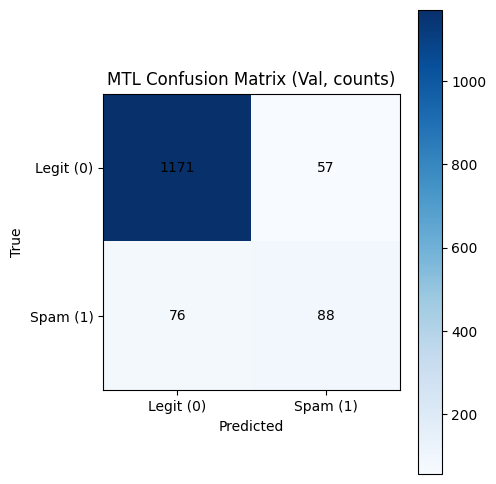


MTL Confusion Matrix (Val, normalized)
[[0.95358306 0.04641694]
 [0.46341463 0.53658537]]


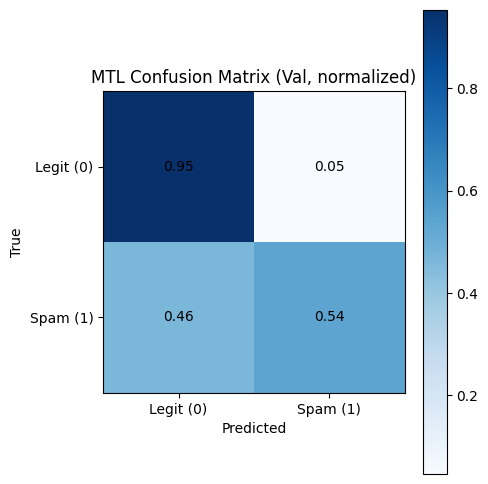


MTL Confusion Matrix (Test, counts)
[[1377   67]
 [  90  104]]


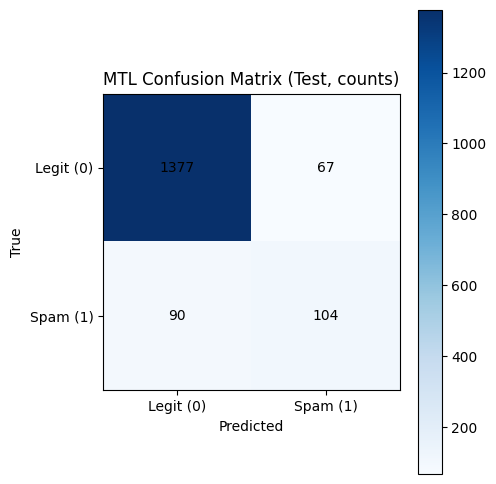


MTL Confusion Matrix (Test, normalized)
[[0.95360111 0.04639889]
 [0.46391753 0.53608247]]


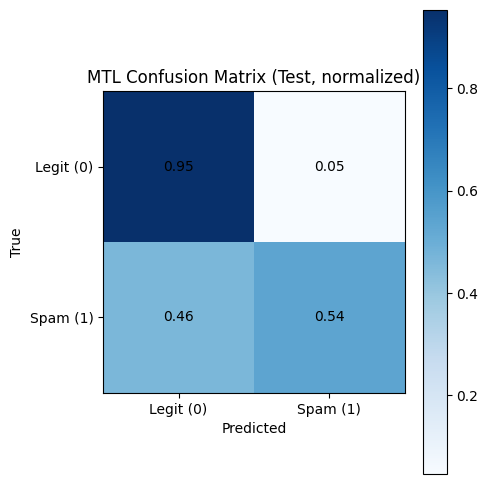


Classification report (TEST – Spam):
              precision    recall  f1-score   support

           0      0.939     0.954     0.946      1444
           1      0.608     0.536     0.570       194

    accuracy                          0.904      1638
   macro avg      0.773     0.745     0.758      1638
weighted avg      0.900     0.904     0.902      1638


Classification report (TEST – Category):
                                           precision    recall  f1-score   support

   arts, culture, entertainment and media      0.889     0.851     0.870        47
                  conflict, war and peace      0.915     0.959     0.937       123
                   crime, law and justice      0.825     0.857     0.841        77
disaster, accident and emergency incident      0.857     0.686     0.762        70
            economy, business and finance      0.806     0.847     0.826        59
                                education      0.804     0.837     0.820        98
           

In [ ]:
#10 Experiment 3 : Multitask (Spam + Category) with shared encoder

import random, numpy as np, pandas as pd, torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import (
    precision_recall_fscore_support, accuracy_score, roc_auc_score,
    confusion_matrix, classification_report, f1_score
)
import matplotlib.pyplot as plt


SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

# Config
MODEL_NAME = "roberta-base"   
MAX_LEN = 192
BATCH_TRAIN = 8
BATCH_EVAL  = 32
EPOCHS = 4
LR = 2e-5
ALPHA = 1.0   # weight for spam loss
BETA  = 1.0   # weight for category loss
USE_SAMPLE_CONFIDENCE = False
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# Load data
train = pd.read_csv("processed/train.csv")
val   = pd.read_csv("processed/val.csv")
test  = pd.read_csv("processed/test.csv")


# Encode categories (ensure same mapping across splits)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train["category_encoded"] = le.fit_transform(train["category_level_1"].astype(str))
val["category_encoded"]   = le.transform(val["category_level_1"].astype(str))
test["category_encoded"]  = le.transform(test["category_level_1"].astype(str))
cats = list(le.classes_)
num_categories = len(cats)

def get_text(df):
    if "text" in df.columns: return df["text"].fillna("").astype(str)
    return (df["title"].fillna("") + " " + df["content"].fillna("")).astype(str)

train_texts, val_texts, test_texts = get_text(train), get_text(val), get_text(test)

y_train_spam = train["spam_label_weak"].astype(int).values
y_val_spam   = val["spam_label_weak"].astype(int).values
y_test_spam  = test["spam_label_weak"].astype(int).values

y_train_cat = train["category_encoded"].astype(int).values
y_val_cat   = val["category_encoded"].astype(int).values
y_test_cat  = test["category_encoded"].astype(int).values

# class weights
def compute_bin_class_weights(y):
    c = Counter(y); N = len(y)
    return torch.tensor([N/(2.0*c.get(0,1)), N/(2.0*c.get(1,1))], dtype=torch.float)

def compute_mc_class_weights(y):
    c = Counter(y); N = len(y); C = len(c)
    return torch.tensor([N/(C*c[i]) for i in range(C)], dtype=torch.float)

SPAM_CLASS_WEIGHTS = compute_bin_class_weights(y_train_spam).to(DEVICE)
CAT_CLASS_WEIGHTS  = compute_mc_class_weights(y_train_cat).to(DEVICE)

# confidences
conf_train = train.get("spam_confidence", pd.Series(np.ones(len(train)))).astype(float).values
conf_val   = val.get("spam_confidence",   pd.Series(np.ones(len(val)))).astype(float).values
conf_test  = test.get("spam_confidence",  pd.Series(np.ones(len(test)))).astype(float).values


# Dataloaders
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

class MTLDataset(Dataset):
    def __init__(self, texts, y_spam, y_cat, confidences):
        self.texts = list(texts); self.y_spam = y_spam; self.y_cat = y_cat; self.conf = confidences
    def __len__(self): return len(self.y_spam)
    def __getitem__(self, i):
        enc = tokenizer(self.texts[i], truncation=True, padding="max_length", max_length=MAX_LEN)
        item = {k: torch.tensor(v) for k,v in enc.items()}
        item["spam"] = torch.tensor(self.y_spam[i], dtype=torch.long)
        item["cat"]  = torch.tensor(self.y_cat[i],  dtype=torch.long)
        item["conf"] = torch.tensor(self.conf[i],   dtype=torch.float)
        return item

dl_train = DataLoader(MTLDataset(train_texts, y_train_spam, y_train_cat, conf_train), batch_size=BATCH_TRAIN, shuffle=True)
dl_val   = DataLoader(MTLDataset(val_texts,   y_val_spam,   y_val_cat,   conf_val), batch_size=BATCH_EVAL)
dl_test  = DataLoader(MTLDataset(test_texts,  y_test_spam,  y_test_cat,  conf_test), batch_size=BATCH_EVAL)


# Shared encoder + 2 heads
class MTLSpamCat(nn.Module):
    def __init__(self, base_model_name, num_categories, hidden=768, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base_model_name)
        self.dropout = nn.Dropout(dropout)
        self.spam_head = nn.Linear(hidden, 2)              # binary
        self.cat_head  = nn.Linear(hidden, num_categories) # multi-class
    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]   # CLS-like token for DistilBERT/RoBERTa
        h = self.dropout(cls)
        return self.spam_head(h), self.cat_head(h)

model = MTLSpamCat(MODEL_NAME, num_categories).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR)
num_steps = len(dl_train) * EPOCHS
sched = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1*num_steps), num_training_steps=num_steps
)


# Train/Eval loop
def train_or_eval(dataloader, train_mode=True):
    model.train(train_mode)
    total_loss, yS_all, pS_all, yC_all, pC_all = 0.0, [], [], [], []

    for b in dataloader:
        ids, att = b["input_ids"].to(DEVICE), b["attention_mask"].to(DEVICE)
        yS, yC, conf = b["spam"].to(DEVICE), b["cat"].to(DEVICE), b["conf"].to(DEVICE)

        spam_logits, cat_logits = model(ids, att)

        ce_spam = F.cross_entropy(spam_logits, yS, weight=SPAM_CLASS_WEIGHTS, reduction='none')
        ce_cat  = F.cross_entropy(cat_logits,  yC, weight=CAT_CLASS_WEIGHTS)

        loss_spam = (ce_spam * conf).mean() if USE_SAMPLE_CONFIDENCE else ce_spam.mean()
        loss = ALPHA * loss_spam + BETA * ce_cat

        if train_mode:
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); sched.step()

        total_loss += loss.item() * ids.size(0)

        with torch.no_grad():
            p_spam = torch.softmax(spam_logits, dim=-1)[:,1]
            p_cat  = torch.softmax(cat_logits,  dim=-1).argmax(-1)
            yS_all.append(yS.cpu().numpy()); pS_all.append(p_spam.cpu().numpy())
            yC_all.append(yC.cpu().numpy()); pC_all.append(p_cat.cpu().numpy())

    yS_all = np.concatenate(yS_all); pS_all = np.concatenate(pS_all)
    yC_all = np.concatenate(yC_all); pC_all = np.concatenate(pC_all)

    avg_loss = total_loss / len(yS_all)

    # spam metrics
    predS = (pS_all >= 0.5).astype(int)
    pS, rS, fS, _ = precision_recall_fscore_support(yS_all, predS, average='binary', zero_division=0)
    accS = accuracy_score(yS_all, predS); aucS = roc_auc_score(yS_all, pS_all)

    # category metrics 
    accC = accuracy_score(yC_all, pC_all)
    f1C  = f1_score(yC_all, pC_all, average='macro')

    return avg_loss, (accS,pS,rS,fS,aucS), (accC,f1C), (yS_all, pS_all)

def threshold_sweep(y_true, y_prob, lo=0.2, hi=0.8, steps=25):
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(lo, hi, steps):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f1 > best_f1: best_f1, best_t = f1, float(t)
    return best_t, best_f1

def eval_at_threshold(dataloader, thresh=0.5, tag="VAL"):
    model.eval()
    yS, pS, yC, pC = [], [], [], []
    with torch.no_grad():
        for b in dataloader:
            ids=b["input_ids"].to(DEVICE); att=b["attention_mask"].to(DEVICE)
            ys=b["spam"].cpu().numpy(); yc=b["cat"].cpu().numpy()
            s_logits, c_logits = model(ids, att)
            p_spam = torch.softmax(s_logits, dim=-1)[:,1].cpu().numpy()
            yS.append(ys); pS.append(p_spam)
            yC.append(yc); pC.append(torch.softmax(c_logits, dim=-1).argmax(-1).cpu().numpy())

    yS = np.concatenate(yS); pS = np.concatenate(pS)
    yC = np.concatenate(yC); pC = np.concatenate(pC)

    predS = (pS >= thresh).astype(int)
    p,r,f,_ = precision_recall_fscore_support(yS, predS, average='binary', zero_division=0)
    acc = accuracy_score(yS, predS); auc = roc_auc_score(yS, pS)
    accC = accuracy_score(yC, pC); f1C  = f1_score(yC, pC, average='macro')

    print(f"[{tag}] Spam@{thresh:.2f}: Acc {acc:.3f}  P {p:.3f}  R {r:.3f}  F1 {f:.3f}  AUC {auc:.3f}  |  "
          f"Category Acc {accC:.3f}  MacroF1 {f1C:.3f}")

    return (yS, predS), (yC, pC), (acc,p,r,f,auc), (accC,f1C)

def show_cm(y_true, y_pred, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    print(f"\n{title}\n{cm}")
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest', cmap="Blues")
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Legit (0)','Spam (1)']); ax.set_yticklabels(['Legit (0)','Spam (1)'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:.2f}" if normalize else f"{cm[i,j]:.0f}",
                    ha="center", va="center")
    fig.colorbar(im); plt.tight_layout(); plt.show()


# Train

best_f1 = -1.0
for epoch in range(1, EPOCHS+1):
    tr_loss, (accS,pS,rS,fS,aucS), (accC,f1C), _ = train_or_eval(dl_train, True)
    va_loss, (vaccS,vpS,vrS,vfS,vaucS), (vaccC,vf1C), (y_val_all, p_val_all) = train_or_eval(dl_val, False)
    print(f"Epoch {epoch}: "
          f"Train: Spam F1 {fS:.3f} AUC {aucS:.3f} | Cat Acc {accC:.3f} MF1 {f1C:.3f} || "
          f"Val: Spam F1 {vfS:.3f} AUC {vaucS:.3f} | Cat Acc {vaccC:.3f} MF1 {vf1C:.3f}")
    if vfS > best_f1:
        best_f1 = vfS
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}  # store on CPU to avoid GPU refs


# Reload best, threshold tuning, final eval

model.load_state_dict(best_state)
t_star, f1_star = threshold_sweep(y_val_all, p_val_all, lo=0.2, hi=0.8, steps=25)
print(f"\nBest spam threshold on Validation: {t_star:.2f} (F1={f1_star:.3f})")

# Eval at tuned threshold
(val_yS, val_predS), (val_yC, val_predC), val_spam_metrics, val_cat_metrics = eval_at_threshold(dl_val,  t_star, "VAL")
(tst_yS, tst_predS), (tst_yC, tst_predC), tst_spam_metrics, tst_cat_metrics = eval_at_threshold(dl_test, t_star, "TEST")


# Confusion matrices and reports

show_cm(val_yS, val_predS, "MTL Confusion Matrix (Val, counts)")
show_cm(val_yS, val_predS, "MTL Confusion Matrix (Val, normalized)", normalize=True)
show_cm(tst_yS, tst_predS, "MTL Confusion Matrix (Test, counts)")
show_cm(tst_yS, tst_predS, "MTL Confusion Matrix (Test, normalized)", normalize=True)

print("\nClassification report (TEST - Spam):")
print(classification_report(tst_yS, tst_predS, digits=3))

print("\nClassification report (TEST - Category):")
print(classification_report(tst_yC, tst_predC, digits=3, target_names=cats))


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1: Train: Spam F1 0.239 AUC 0.610 | Cat Acc 0.806 MF1 0.826 || Val:   Spam F1 0.400 AUC 0.758 | Cat Acc 0.997 MF1 0.996
Epoch 2: Train: Spam F1 0.381 AUC 0.723 | Cat Acc 1.000 MF1 1.000 || Val:   Spam F1 0.473 AUC 0.820 | Cat Acc 1.000 MF1 1.000
Epoch 3: Train: Spam F1 0.521 AUC 0.817 | Cat Acc 1.000 MF1 1.000 || Val:   Spam F1 0.408 AUC 0.801 | Cat Acc 1.000 MF1 1.000
Epoch 4: Train: Spam F1 0.660 AUC 0.904 | Cat Acc 1.000 MF1 1.000 || Val:   Spam F1 0.490 AUC 0.840 | Cat Acc 1.000 MF1 1.000

Best spam threshold on Validation: 0.20 (F1=0.511)
[VAL] Spam@0.20: Acc 0.908  P 0.684  R 0.409  F1 0.511  AUC 0.840  |  Category Acc 1.000  MacroF1 1.000
[TEST] Spam@0.20: Acc 0.905  P 0.658  R 0.407  F1 0.503  AUC 0.812  |  Category Acc 1.000  MacroF1 1.000

MTL (Spam+Cat) – Spam CM (Val, counts)
[[1197   31]
 [  97   67]]


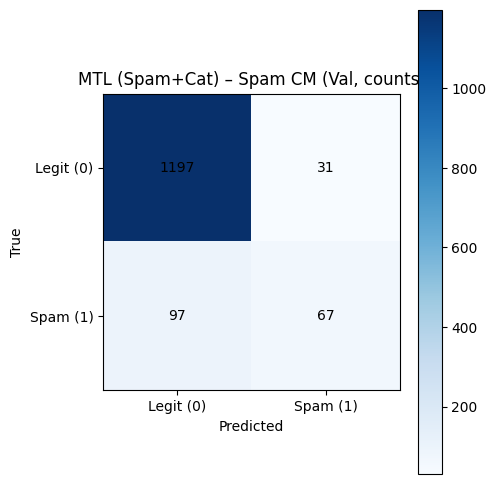


MTL (Spam+Cat) – Spam CM (Val, normalized)
[[0.9747557  0.0252443 ]
 [0.59146341 0.40853659]]


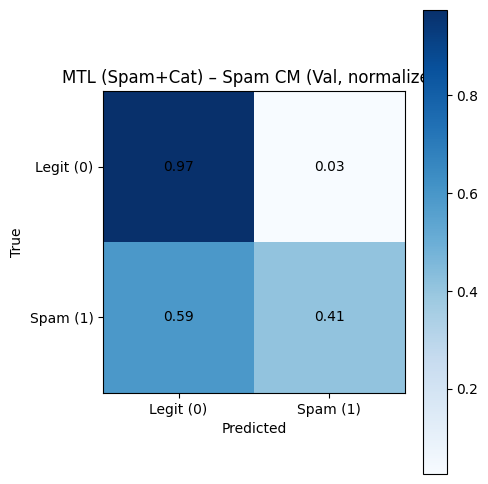


MTL (Spam+Cat) – Spam CM (Test, counts)
[[1403   41]
 [ 115   79]]


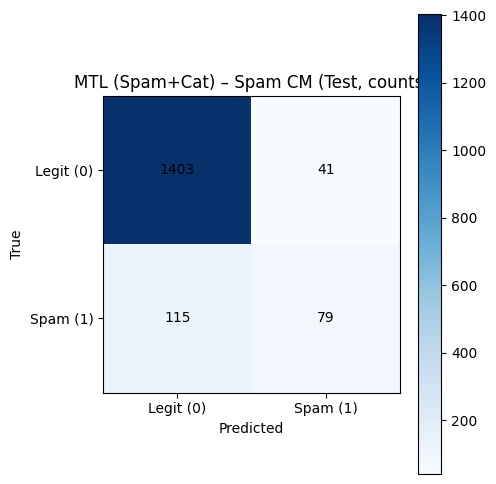


MTL (Spam+Cat) – Spam CM (Test, normalized)
[[0.97160665 0.02839335]
 [0.59278351 0.40721649]]


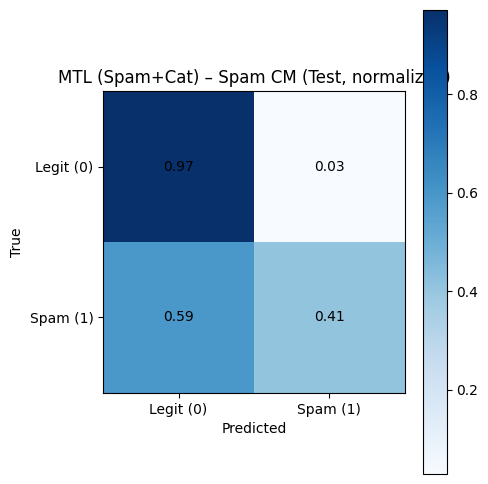


Classification report (TEST – Spam):
              precision    recall  f1-score   support

           0      0.924     0.972     0.947      1444
           1      0.658     0.407     0.503       194

    accuracy                          0.905      1638
   macro avg      0.791     0.689     0.725      1638
weighted avg      0.893     0.905     0.895      1638


Classification report (TEST – Category):
                                           precision    recall  f1-score   support

   arts, culture, entertainment and media      1.000     1.000     1.000        47
                  conflict, war and peace      1.000     1.000     1.000       123
                   crime, law and justice      1.000     1.000     1.000        77
disaster, accident and emergency incident      1.000     1.000     1.000        70
            economy, business and finance      1.000     1.000     1.000        59
                                education      1.000     1.000     1.000        98
           

In [ ]:
#11 Experiment 4 : MTL (Spam + Category)
# Shared encoder + 2 heads with category metadata token 


import random, numpy as np, pandas as pd, torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import (
    precision_recall_fscore_support, accuracy_score, roc_auc_score,
    confusion_matrix, classification_report, f1_score
)
import matplotlib.pyplot as plt


SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False


# Config
MODEL_NAME = "roberta-base"  # try "roberta-base" as an ablation
MAX_LEN = 192
BATCH_TRAIN = 8
BATCH_EVAL  = 32
EPOCHS = 4
LR = 2e-5

ALPHA = 1.3        # spam loss weight (↑ to push recall)
BETA  = 1.0        # category loss weight
USE_SAMPLE_CONFIDENCE = False

USE_SOURCE_TOKEN = False  # if True, prepend [SRC_xxx] to text as input only (no source head)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load data
train = pd.read_csv("processed/train.csv")
val   = pd.read_csv("processed/val.csv")
test  = pd.read_csv("processed/test.csv")

# Encode categories
from sklearn.preprocessing import LabelEncoder
le_cat = LabelEncoder()
train["category_encoded"] = le_cat.fit_transform(train["category_level_1"].astype(str))
val["category_encoded"]   = le_cat.transform(val["category_level_1"].astype(str))
test["category_encoded"]  = le_cat.transform(test["category_level_1"].astype(str))
cat_labels = list(le_cat.classes_)
NUM_CATS = len(cat_labels)

# Text + metadata tokens
def base_text(df):
    if "text" in df.columns: return df["text"].fillna("").astype(str)
    return (df["title"].fillna("") + " " + df["content"].fillna("")).astype(str)

def add_meta_tokens(texts, df, use_source=False, cap_sources=200):
    # cap_sources
    if use_source:
        src_counts = df["source"].fillna("UNKNOWN").astype(str).value_counts()
        keep_src = set(src_counts.head(cap_sources).index)
    meta = []
    for t, c in zip(texts, df["category_level_1"].astype(str)):
        tok = f"[CAT_{c.upper().replace(' ','_')}]"
        if use_source:
            s = str(df.loc[t.index if hasattr(t, 'index') else df.index, "source"])  # safety for Pandas
        meta.append(tok + " " + t)
    return pd.Series(meta, index=texts.index)

def add_meta_tokens_safe(texts, df, use_source=False, cap_sources=200):
    if use_source:
        src_counts = df["source"].fillna("UNKNOWN").astype(str).value_counts()
        keep_src = set(src_counts.head(cap_sources).index)
        meta = []
        for t, s, c in zip(texts, df["source"].fillna("UNKNOWN").astype(str), df["category_level_1"].astype(str)):
            s_ = s if s in keep_src else "OTHER"
            meta.append(f"[CAT_{c.upper().replace(' ','_')}] [SRC_{s_.upper().replace(' ','_')}] {t}")
        return pd.Series(meta, index=texts.index)
    else:
        return pd.Series([f"[CAT_{c.upper().replace(' ','_')}] {t}"
                          for t, c in zip(texts, df["category_level_1"].astype(str))],
                         index=texts.index)

train_texts = base_text(train); val_texts = base_text(val); test_texts = base_text(test)
train_texts = add_meta_tokens_safe(train_texts, train, use_source=USE_SOURCE_TOKEN)
val_texts   = add_meta_tokens_safe(val_texts,   val,   use_source=USE_SOURCE_TOKEN)
test_texts  = add_meta_tokens_safe(test_texts,  test,  use_source=USE_SOURCE_TOKEN)

# Targets
y_train_spam = train["spam_label_weak"].astype(int).values
y_val_spam   = val["spam_label_weak"].astype(int).values
y_test_spam  = test["spam_label_weak"].astype(int).values
y_train_cat  = train["category_encoded"].astype(int).values
y_val_cat    = val["category_encoded"].astype(int).values
y_test_cat   = test["category_encoded"].astype(int).values

# class weights
def compute_bin_class_weights(y):
    c = Counter(y); N = len(y)
    return torch.tensor([N/(2.0*c.get(0,1)), N/(2.0*c.get(1,1))], dtype=torch.float)

def compute_mc_class_weights(y):
    c = Counter(y); N = len(y); C = len(c)
    return torch.tensor([N/(C*c[i]) for i in range(C)], dtype=torch.float)

SPAM_W = compute_bin_class_weights(y_train_spam).to(DEVICE)
CAT_W  = compute_mc_class_weights(y_train_cat).to(DEVICE)

# confidences 
conf_train = train.get("spam_confidence", pd.Series(np.ones(len(train)))).astype(float).values
conf_val   = val.get("spam_confidence",   pd.Series(np.ones(len(val)))).astype(float).values
conf_test  = test.get("spam_confidence",  pd.Series(np.ones(len(test)))).astype(float).values


# Dataloaders

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

class MTLDataset(Dataset):
    def __init__(self, texts, y_spam, y_cat, confidences):
        self.texts = list(texts); self.y_spam = y_spam; self.y_cat = y_cat; self.conf = confidences
    def __len__(self): return len(self.y_spam)
    def __getitem__(self, i):
        enc = tokenizer(self.texts[i], truncation=True, padding="max_length", max_length=MAX_LEN)
        item = {k: torch.tensor(v) for k,v in enc.items()}
        item["spam"] = torch.tensor(self.y_spam[i], dtype=torch.long)
        item["cat"]  = torch.tensor(self.y_cat[i],  dtype=torch.long)
        item["conf"] = torch.tensor(self.conf[i],   dtype=torch.float)
        return item

dl_train = DataLoader(MTLDataset(train_texts, y_train_spam, y_train_cat, conf_train), batch_size=BATCH_TRAIN, shuffle=True)
dl_val   = DataLoader(MTLDataset(val_texts,   y_val_spam,   y_val_cat,   conf_val), batch_size=BATCH_EVAL)
dl_test  = DataLoader(MTLDataset(test_texts,  y_test_spam,  y_test_cat,  conf_test), batch_size=BATCH_EVAL)


# Shared encoder + 2 heads

class MTLSpamCat(nn.Module):
    def __init__(self, base_model_name, num_categories, hidden=768, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base_model_name)
        self.dropout = nn.Dropout(dropout)
        self.spam_head = nn.Linear(hidden, 2)
        self.cat_head  = nn.Linear(hidden, num_categories)
    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]
        h = self.dropout(cls)
        return self.spam_head(h), self.cat_head(h)

model = MTLSpamCat(MODEL_NAME, NUM_CATS).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR)
num_steps = len(dl_train) * EPOCHS
sched = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*num_steps), num_training_steps=num_steps)


# Train/Eval loop

def train_or_eval(dataloader, train_mode=True):
    model.train(train_mode)
    total_loss, yS_all, pS_all, yC_all, pC_all = 0.0, [], [], [], []

    for b in dataloader:
        ids, att = b["input_ids"].to(DEVICE), b["attention_mask"].to(DEVICE)
        yS, yC, conf = b["spam"].to(DEVICE), b["cat"].to(DEVICE), b["conf"].to(DEVICE)

        s_logits, c_logits = model(ids, att)

        ce_spam = F.cross_entropy(s_logits, yS, weight=SPAM_W, reduction='none')
        ce_cat  = F.cross_entropy(c_logits,  yC, weight=CAT_W)

        loss_spam = (ce_spam * conf).mean() if USE_SAMPLE_CONFIDENCE else ce_spam.mean()
        loss = ALPHA * loss_spam + BETA * ce_cat

        if train_mode:
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); sched.step()

        total_loss += loss.item() * ids.size(0)

        with torch.no_grad():
            p_spam = torch.softmax(s_logits, dim=-1)[:,1]
            p_cat  = torch.softmax(c_logits,  dim=-1).argmax(-1)
            yS_all.append(yS.cpu().numpy()); pS_all.append(p_spam.cpu().numpy())
            yC_all.append(yC.cpu().numpy()); pC_all.append(p_cat.cpu().numpy())

    yS_all = np.concatenate(yS_all); pS_all = np.concatenate(pS_all)
    yC_all = np.concatenate(yC_all); pC_all = np.concatenate(pC_all)

    avg_loss = total_loss / len(yS_all)

    predS = (pS_all >= 0.5).astype(int)  # progress metric only; we will tune threshold later
    pS, rS, fS, _ = precision_recall_fscore_support(yS_all, predS, average='binary', zero_division=0)
    accS = accuracy_score(yS_all, predS); aucS = roc_auc_score(yS_all, pS_all)

    accC = accuracy_score(yC_all, pC_all)
    f1C  = f1_score(yC_all, pC_all, average='macro')

    return avg_loss, (accS,pS,rS,fS,aucS), (accC,f1C), (yS_all, pS_all)

def threshold_sweep(y_true, y_prob, lo=0.2, hi=0.8, steps=25):
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(lo, hi, steps):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f1 > best_f1: best_f1, best_t = f1, float(t)
    return best_t, best_f1

def eval_at_threshold(dataloader, thresh=0.5, tag="VAL"):
    model.eval()
    yS, pS, yC_t, yC_p = [], [], [], []
    with torch.no_grad():
        for b in dataloader:
            ids=b["input_ids"].to(DEVICE); att=b["attention_mask"].to(DEVICE)
            ys=b["spam"].cpu().numpy(); yc=b["cat"].cpu().numpy()
            s_logits, c_logits = model(ids, att)
            p_spam = torch.softmax(s_logits, dim=-1)[:,1].cpu().numpy()
            yS.append(ys); pS.append(p_spam)
            yC_t.append(yc); yC_p.append(torch.softmax(c_logits, dim=-1).argmax(-1).cpu().numpy())

    yS = np.concatenate(yS); pS = np.concatenate(pS)
    yC_t, yC_p = np.concatenate(yC_t), np.concatenate(yC_p)

    predS = (pS >= thresh).astype(int)
    p,r,f,_ = precision_recall_fscore_support(yS, predS, average='binary', zero_division=0)
    acc = accuracy_score(yS, predS); auc = roc_auc_score(yS, pS)
    accC = accuracy_score(yC_t, yC_p); f1C  = f1_score(yC_t, yC_p, average='macro')

    print(f"[{tag}] Spam@{thresh:.2f}: Acc {acc:.3f}  P {p:.3f}  R {r:.3f}  F1 {f:.3f}  AUC {auc:.3f}  |  "
          f"Category Acc {accC:.3f}  MacroF1 {f1C:.3f}")

    return (yS, predS), (yC_t, yC_p), (acc,p,r,f,auc), (accC,f1C)

def show_cm(y_true, y_pred, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    print(f"\n{title}\n{cm}")
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest', cmap="Blues")
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Legit (0)','Spam (1)']); ax.set_yticklabels(['Legit (0)','Spam (1)'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:.2f}" if normalize else f"{cm[i,j]:.0f}", ha="center", va="center")
    fig.colorbar(im); plt.tight_layout(); plt.show()


# Train

best_f1 = -1.0
for epoch in range(1, EPOCHS+1):
    tr_loss, (accS,pS,rS,fS,aucS), (accC,f1C), _ = train_or_eval(dl_train, True)
    va_loss, (vaccS,vpS,vrS,vfS,vaucS), (vaccC,vf1C), (y_val_all, p_val_all) = train_or_eval(dl_val, False)
    print(f"Epoch {epoch}: "
          f"Train: Spam F1 {fS:.3f} AUC {aucS:.3f} | Cat Acc {accC:.3f} MF1 {f1C:.3f} || "
          f"Val:   Spam F1 {vfS:.3f} AUC {vaucS:.3f} | Cat Acc {vaccC:.3f} MF1 {vf1C:.3f}")
    if vfS > best_f1:
        best_f1 = vfS
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}


# Reload best, threshold tuning, final eval

model.load_state_dict(best_state)
t_star, f1_star = threshold_sweep(y_val_all, p_val_all, lo=0.2, hi=0.8, steps=25)
print(f"\nBest spam threshold on Validation: {t_star:.2f} (F1={f1_star:.3f})")

(val_yS, val_predS), (val_yC, val_predC), val_spam, val_cat = eval_at_threshold(dl_val,  t_star, "VAL")
(tst_yS, tst_predS), (tst_yC, tst_predC), tst_spam, tst_cat = eval_at_threshold(dl_test, t_star, "TEST")


# Confusion matrices and reports

show_cm(val_yS, val_predS, "MTL (Spam+Cat) – Spam CM (Val, counts)")
show_cm(val_yS, val_predS, "MTL (Spam+Cat) – Spam CM (Val, normalized)", normalize=True)
show_cm(tst_yS, tst_predS, "MTL (Spam+Cat) – Spam CM (Test, counts)")
show_cm(tst_yS, tst_predS, "MTL (Spam+Cat) – Spam CM (Test, normalized)", normalize=True)

print("\nClassification report (TEST – Spam):")
print(classification_report(tst_yS, tst_predS, digits=3))

print("\nClassification report (TEST – Category):")
print(classification_report(tst_yC, tst_predC, digits=3, target_names=cat_labels))


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1: Train: Spam F1 0.292 AUC 0.687 | Cat Acc 0.536 MF1 0.544 | Src Acc 0.038 MF1 0.012 || Val:   Spam F1 0.305 AUC 0.803 | Cat Acc 0.787 MF1 0.784 | Src Acc 0.108 MF1 0.038
Epoch 2: Train: Spam F1 0.438 AUC 0.814 | Cat Acc 0.841 MF1 0.842 | Src Acc 0.130 MF1 0.041 || Val:   Spam F1 0.504 AUC 0.844 | Cat Acc 0.828 MF1 0.832 | Src Acc 0.162 MF1 0.062
Epoch 3: Train: Spam F1 0.601 AUC 0.919 | Cat Acc 0.900 MF1 0.904 | Src Acc 0.196 MF1 0.073 || Val:   Spam F1 0.523 AUC 0.853 | Cat Acc 0.849 MF1 0.848 | Src Acc 0.209 MF1 0.092
Epoch 4: Train: Spam F1 0.754 AUC 0.968 | Cat Acc 0.927 MF1 0.930 | Src Acc 0.245 MF1 0.124 || Val:   Spam F1 0.524 AUC 0.848 | Cat Acc 0.858 MF1 0.858 | Src Acc 0.232 MF1 0.116

Best spam threshold on Validation: 0.60 (F1=0.545)
[VAL] Spam@0.60: Acc 0.909 P 0.661 R 0.463 F1 0.545 AUC 0.848 | Cat Acc 0.858 MF1 0.858 | Src Acc 0.232 MF1 0.116
[TEST] Spam@0.60: Acc 0.907 P 0.647 R 0.464 F1 0.541 AUC 0.827 | Cat Acc 0.846 MF1 0.854 | Src Acc 0.234 MF1 0.101

Propos

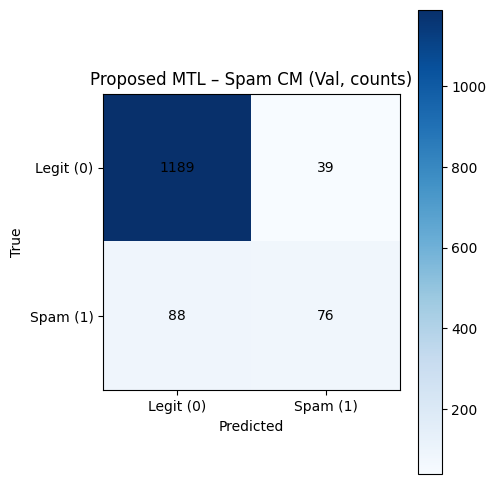


Proposed MTL – Spam CM (Val, normalized)
[[0.96824104 0.03175896]
 [0.53658537 0.46341463]]


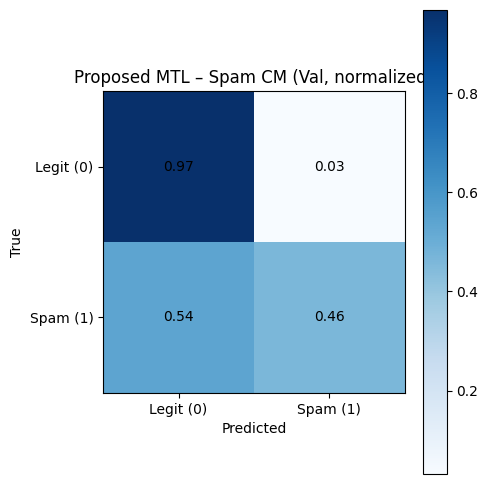


Proposed MTL – Spam CM (Test, counts)
[[1395   49]
 [ 104   90]]


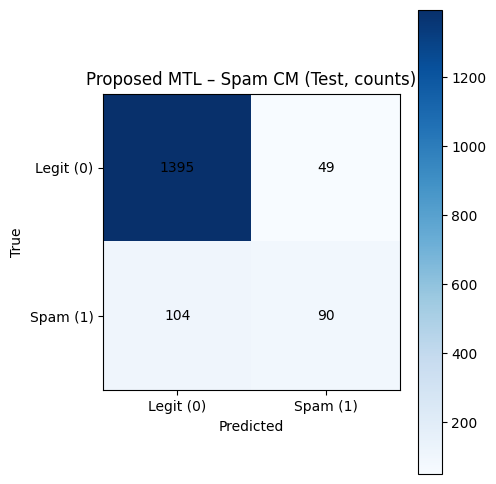


Proposed MTL – Spam CM (Test, normalized)
[[0.96606648 0.03393352]
 [0.53608247 0.46391753]]


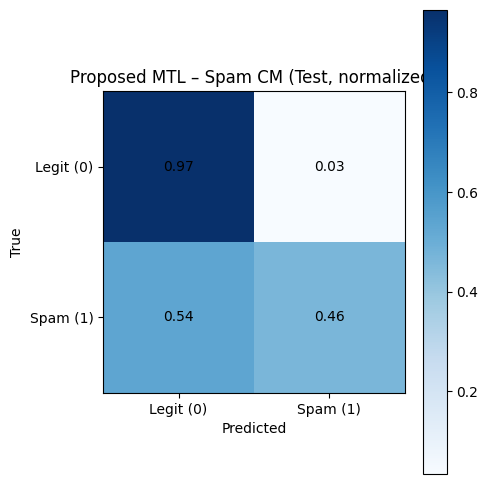


Classification report (TEST – Spam):
              precision    recall  f1-score   support

           0      0.931     0.966     0.948      1444
           1      0.647     0.464     0.541       194

    accuracy                          0.907      1638
   macro avg      0.789     0.715     0.744      1638
weighted avg      0.897     0.907     0.900      1638


Classification report (TEST – Category):
                                           precision    recall  f1-score   support

   arts, culture, entertainment and media      0.891     0.872     0.882        47
                  conflict, war and peace      0.902     0.902     0.902       123
                   crime, law and justice      0.841     0.896     0.868        77
disaster, accident and emergency incident      0.803     0.757     0.779        70
            economy, business and finance      0.847     0.847     0.847        59
                                education      0.804     0.837     0.820        98
           

In [ ]:
# ============================================
# Experiment 5 : MTL (Spam + Category + Source)
# Model: RoBERTa shared encoder + 3 heads
# - No metadata tokens (no leakage)
# ============================================

import random, numpy as np, pandas as pd, torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import (
    precision_recall_fscore_support, accuracy_score, roc_auc_score,
    confusion_matrix, classification_report, f1_score
)
import matplotlib.pyplot as plt


SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False


# Config
MODEL_NAME = "roberta-base"
MAX_LEN = 192
BATCH_TRAIN = 8
BATCH_EVAL  = 32
EPOCHS = 4
LR = 2e-5

ALPHA = 1.3   # spam loss weight
BETA  = 1.0   # category loss weight
GAMMA = 0.5   # source loss weight
USE_SAMPLE_CONFIDENCE = False  # set True if you want to weight spam loss by confidence

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# Load data
train = pd.read_csv("processed/train.csv")
val   = pd.read_csv("processed/val.csv")
test  = pd.read_csv("processed/test.csv")


# Safe union-fit encoders (prevents unseen-label errors)

from sklearn.preprocessing import LabelEncoder

def fit_union_labelencoder(*series_list, fill="UNKNOWN"):
    le = LabelEncoder()
    all_vals = pd.concat([s.fillna(fill).astype(str) for s in series_list], ignore_index=True)
    le.fit(all_vals)
    return le

# Category encoder across train+val+test
le_cat = fit_union_labelencoder(train["category_level_1"], val["category_level_1"], test["category_level_1"], fill="OTHER")
train["category_encoded"] = le_cat.transform(train["category_level_1"].fillna("OTHER").astype(str))
val["category_encoded"]   = le_cat.transform(val["category_level_1"].fillna("OTHER").astype(str))
test["category_encoded"]  = le_cat.transform(test["category_level_1"].fillna("OTHER").astype(str))
cat_labels = list(le_cat.classes_)
NUM_CATS = len(cat_labels)

# Source encoder across train+val+test
le_src = fit_union_labelencoder(train["source"], val["source"], test["source"], fill="UNKNOWN")
train["source_encoded"] = le_src.transform(train["source"].fillna("UNKNOWN").astype(str))
val["source_encoded"]   = le_src.transform(val["source"].fillna("UNKNOWN").astype(str))
test["source_encoded"]  = le_src.transform(test["source"].fillna("UNKNOWN").astype(str))
src_labels = list(le_src.classes_)
NUM_SRCS = len(src_labels)


# Text fields
def get_text(df):
    # prefer 'text' if present, else concatenate title + content
    if "text" in df.columns:
        return df["text"].fillna("").astype(str)
    return (df["title"].fillna("") + " " + df["content"].fillna("")).astype(str)

train_texts = get_text(train)
val_texts   = get_text(val)
test_texts  = get_text(test)

# Targets
y_train_spam = train["spam_label_weak"].astype(int).values
y_val_spam   = val["spam_label_weak"].astype(int).values
y_test_spam  = test["spam_label_weak"].astype(int).values

y_train_cat = train["category_encoded"].astype(int).values
y_val_cat   = val["category_encoded"].astype(int).values
y_test_cat  = test["category_encoded"].astype(int).values

y_train_src = train["source_encoded"].astype(int).values
y_val_src   = val["source_encoded"].astype(int).values
y_test_src  = test["source_encoded"].astype(int).values


# Class weights and confidences

def compute_bin_class_weights(y):
    c = Counter(y); N = len(y)
    return torch.tensor([N/(2.0*c.get(0,1)), N/(2.0*c.get(1,1))], dtype=torch.float)

def compute_mc_class_weights(y, num_classes):
    c = Counter(y); N = len(y)
    return torch.tensor([N/(num_classes*c.get(i,1)) for i in range(num_classes)], dtype=torch.float)

SPAM_W = compute_bin_class_weights(y_train_spam).to(DEVICE)
CAT_W  = compute_mc_class_weights(y_train_cat, NUM_CATS).to(DEVICE)
SRC_W  = compute_mc_class_weights(y_train_src, NUM_SRCS).to(DEVICE)

conf_train = train.get("spam_confidence", pd.Series(np.ones(len(train)))).astype(float).values
conf_val   = val.get("spam_confidence",   pd.Series(np.ones(len(val)))).astype(float).values
conf_test  = test.get("spam_confidence",  pd.Series(np.ones(len(test)))).astype(float).values


# Dataloaders

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

class MTLDataset(Dataset):
    def __init__(self, texts, y_spam, y_cat, y_src, confidences):
        self.texts = list(texts); self.y_spam = y_spam; self.y_cat = y_cat; self.y_src = y_src; self.conf = confidences
    def __len__(self): return len(self.y_spam)
    def __getitem__(self, i):
        enc = tokenizer(self.texts[i], truncation=True, padding="max_length", max_length=MAX_LEN)
        item = {k: torch.tensor(v) for k,v in enc.items()}
        item["spam"] = torch.tensor(self.y_spam[i], dtype=torch.long)
        item["cat"]  = torch.tensor(self.y_cat[i],  dtype=torch.long)
        item["src"]  = torch.tensor(self.y_src[i],  dtype=torch.long)
        item["conf"] = torch.tensor(self.conf[i],   dtype=torch.float)
        return item

dl_train = DataLoader(MTLDataset(train_texts, y_train_spam, y_train_cat, y_train_src, conf_train), batch_size=BATCH_TRAIN, shuffle=True)
dl_val   = DataLoader(MTLDataset(val_texts,   y_val_spam,   y_val_cat,   y_val_src,   conf_val),   batch_size=BATCH_EVAL)
dl_test  = DataLoader(MTLDataset(test_texts,  y_test_spam,  y_test_cat,  y_test_src,  conf_test),  batch_size=BATCH_EVAL)


# Model: shared encoder + 3 heads

class MTL_SpamCatSrc(nn.Module):
    def __init__(self, base_model_name, num_cats, num_srcs, hidden=768, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base_model_name)
        self.drop = nn.Dropout(dropout)
        self.spam_head = nn.Linear(hidden, 2)        # binary
        self.cat_head  = nn.Linear(hidden, num_cats) # multi-class
        self.src_head  = nn.Linear(hidden, num_srcs) # multi-class
    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]           
        h = self.drop(cls)
        return self.spam_head(h), self.cat_head(h), self.src_head(h)

model = MTL_SpamCatSrc(MODEL_NAME, NUM_CATS, NUM_SRCS).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR)
num_steps = len(dl_train) * EPOCHS
sched = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*num_steps), num_training_steps=num_steps)


# Train/Eval loop

def train_or_eval(dataloader, train_mode=True):
    model.train(train_mode)
    total_loss, yS_all, pS_all = 0.0, [], []
    yC_true, yC_pred, yR_true, yR_pred = [], [], [], []

    for b in dataloader:
        ids, att = b["input_ids"].to(DEVICE), b["attention_mask"].to(DEVICE)
        yS, yC, yR, conf = b["spam"].to(DEVICE), b["cat"].to(DEVICE), b["src"].to(DEVICE), b["conf"].to(DEVICE)

        s_logits, c_logits, r_logits = model(ids, att)

        ce_spam = F.cross_entropy(s_logits, yS, weight=SPAM_W, reduction='none')
        ce_cat  = F.cross_entropy(c_logits, yC, weight=CAT_W)
        ce_src  = F.cross_entropy(r_logits, yR, weight=SRC_W)

        loss_spam = (ce_spam * conf).mean() if USE_SAMPLE_CONFIDENCE else ce_spam.mean()
        loss = ALPHA * loss_spam + BETA * ce_cat + GAMMA * ce_src

        if train_mode:
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); sched.step()

        total_loss += loss.item() * ids.size(0)

        with torch.no_grad():
            p_spam = torch.softmax(s_logits, dim=-1)[:,1]
            pS_all.append(p_spam.cpu().numpy()); yS_all.append(yS.cpu().numpy())
            yC_true.append(yC.cpu().numpy()); yC_pred.append(torch.softmax(c_logits, dim=-1).argmax(-1).cpu().numpy())
            yR_true.append(yR.cpu().numpy()); yR_pred.append(torch.softmax(r_logits, dim=-1).argmax(-1).cpu().numpy())

    yS_all = np.concatenate(yS_all); pS_all = np.concatenate(pS_all)
    yC_true, yC_pred = np.concatenate(yC_true), np.concatenate(yC_pred)
    yR_true, yR_pred = np.concatenate(yR_true), np.concatenate(yR_pred)

    avg_loss = total_loss / len(yS_all)

    # progress metrics
    predS = (pS_all >= 0.5).astype(int)
    pS, rS, fS, _ = precision_recall_fscore_support(yS_all, predS, average='binary', zero_division=0)
    accS = accuracy_score(yS_all, predS); aucS = roc_auc_score(yS_all, pS_all)

    accC = accuracy_score(yC_true, yC_pred); f1C = f1_score(yC_true, yC_pred, average='macro')
    accR = accuracy_score(yR_true, yR_pred); f1R = f1_score(yR_true, yR_pred, average='macro')

    return avg_loss, (accS,pS,rS,fS,aucS), (accC,f1C), (accR,f1R), (yS_all, pS_all)

def threshold_sweep(y_true, y_prob, lo=0.2, hi=0.8, steps=25):
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(lo, hi, steps):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f1 > best_f1: best_f1, best_t = f1, float(t)
    return best_t, best_f1

def eval_at_threshold(dataloader, thresh=0.5, tag="VAL"):
    model.eval()
    yS, pS, yC_t, yC_p, yR_t, yR_p = [], [], [], [], [], []
    with torch.no_grad():
        for b in dataloader:
            ids=b["input_ids"].to(DEVICE); att=b["attention_mask"].to(DEVICE)
            ys=b["spam"].cpu().numpy(); yc=b["cat"].cpu().numpy(); yr=b["src"].cpu().numpy()
            s_logits, c_logits, r_logits = model(ids, att)
            p_spam = torch.softmax(s_logits, dim=-1)[:,1].cpu().numpy()
            yS.append(ys); pS.append(p_spam)
            yC_t.append(yc); yC_p.append(torch.softmax(c_logits, dim=-1).argmax(-1).cpu().numpy())
            yR_t.append(yr); yR_p.append(torch.softmax(r_logits, dim=-1).argmax(-1).cpu().numpy())

    yS = np.concatenate(yS); pS = np.concatenate(pS)
    yC_t, yC_p = np.concatenate(yC_t), np.concatenate(yC_p)
    yR_t, yR_p = np.concatenate(yR_t), np.concatenate(yR_p)

    predS = (pS >= thresh).astype(int)
    p,r,f,_ = precision_recall_fscore_support(yS, predS, average='binary', zero_division=0)
    acc = accuracy_score(yS, predS); auc = roc_auc_score(yS, pS)

    accC = accuracy_score(yC_t, yC_p); f1C = f1_score(yC_t, yC_p, average='macro')
    accR = accuracy_score(yR_t, yR_p); f1R = f1_score(yR_t, yR_p, average='macro')

    print(f"[{tag}] Spam@{thresh:.2f}: Acc {acc:.3f} P {p:.3f} R {r:.3f} F1 {f:.3f} AUC {auc:.3f} | "
          f"Cat Acc {accC:.3f} MF1 {f1C:.3f} | Src Acc {accR:.3f} MF1 {f1R:.3f}")
    return (yS, predS), (yC_t, yC_p), (yR_t, yR_p), (acc,p,r,f,auc), (accC,f1C), (accR,f1R)

def show_cm(y_true, y_pred, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    print(f"\n{title}\n{cm}")
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest', cmap="Blues")
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Legit (0)','Spam (1)']); ax.set_yticklabels(['Legit (0)','Spam (1)'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:.2f}" if normalize else f"{cm[i,j]:.0f}",
                    ha="center", va="center")
    fig.colorbar(im); plt.tight_layout(); plt.show()

# Train 
best_f1 = -1.0
for epoch in range(1, EPOCHS+1):
    tr_loss, (accS,pS,rS,fS,aucS), (accC,f1C), (accR,f1R), _ = train_or_eval(dl_train, True)
    va_loss, (vaccS,vpS,vrS,vfS,vaucS), (vaccC,vf1C), (vaccR,vf1R), (y_val_all, p_val_all) = train_or_eval(dl_val, False)
    print(f"Epoch {epoch}: "
          f"Train: Spam F1 {fS:.3f} AUC {aucS:.3f} | Cat Acc {accC:.3f} MF1 {f1C:.3f} | Src Acc {accR:.3f} MF1 {f1R:.3f} || "
          f"Val:   Spam F1 {vfS:.3f} AUC {vaucS:.3f} | Cat Acc {vaccC:.3f} MF1 {vf1C:.3f} | Src Acc {vaccR:.3f} MF1 {vf1R:.3f}")
    if vfS > best_f1:
        best_f1 = vfS
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}  # store on CPU


# Reload best, threshold tuning, final eval
model.load_state_dict(best_state)
t_star, f1_star = threshold_sweep(y_val_all, p_val_all, lo=0.2, hi=0.8, steps=25)
print(f"\nBest spam threshold on Validation: {t_star:.2f} (F1={f1_star:.3f})")

(val_yS, val_predS), (val_yC, val_predC), (val_yR, val_predR), val_spam, val_cat, val_src = eval_at_threshold(dl_val,  t_star, "VAL")
(tst_yS, tst_predS), (tst_yC, tst_predC), (tst_yR, tst_predR), tst_spam, tst_cat, tst_src = eval_at_threshold(dl_test, t_star, "TEST")


# Confusion matrices and reports 

show_cm(val_yS, val_predS, "Proposed MTL – Spam CM (Val, counts)")
show_cm(val_yS, val_predS, "Proposed MTL – Spam CM (Val, normalized)", normalize=True)
show_cm(tst_yS, tst_predS, "Proposed MTL – Spam CM (Test, counts)")
show_cm(tst_yS, tst_predS, "Proposed MTL – Spam CM (Test, normalized)", normalize=True)

print("\nClassification report (TEST – Spam):")
print(classification_report(tst_yS, tst_predS, digits=3, zero_division=0))

print("\nClassification report (TEST – Category):")
print(classification_report(tst_yC, tst_predC, digits=3, target_names=cat_labels, zero_division=0))


# Source report

print("\nClassification report (TEST – Source) [present labels only]:")
present_labels = sorted(set(np.unique(tst_yR)) | set(np.unique(tst_predR)))
present_names  = [src_labels[i] for i in present_labels]
print(classification_report(
    tst_yR, tst_predR,
    labels=present_labels,
    target_names=present_names,
    digits=3,
    zero_division=0
))

print("\nClassification report (TEST – Source) [ids 0..19 that actually appear]:")
keep_ids = set(range(20))
mask = np.isin(tst_yR, list(keep_ids)) | np.isin(tst_predR, list(keep_ids))
y_true_sub = tst_yR[mask]
y_pred_sub = tst_predR[mask]
present_0_19 = sorted(set(np.unique(y_true_sub)) | set(np.unique(y_pred_sub)))
present_0_19_names = [src_labels[i] for i in present_0_19]
print(classification_report(
    y_true_sub, y_pred_sub,
    labels=present_0_19,
    target_names=present_0_19_names,
    digits=3,
    zero_division=0
))


# Per-category spam recall

print("\nPer-category spam recall on TEST:")
df_eval = pd.DataFrame({
    "y_true": tst_yS,
    "y_pred": tst_predS,
    "cat": [cat_labels[i] for i in tst_yC]
})

def binary_recall(g):
    _, r, _, _ = precision_recall_fscore_support(g["y_true"], g["y_pred"], average='binary', zero_division=0)
    return r

per_cat_recall = (
    df_eval.groupby("cat")[["y_true","y_pred"]]
           .apply(lambda g: binary_recall(g))
           .sort_values(ascending=False)
)
print(per_cat_recall.head(15))
print("\nLowest categories by spam recall:")
print(per_cat_recall.tail(10))
